# Processing dataset from audio to img 
Structure:
> data:
>>    **dataset_table**: save data frame pickle version of dataset for audio and img

>>    **sp_audio_dataset_mq**: raw data 

>>    **sp_audio_dataset_trim[...]**: processed dataset (trimmed in this case) audio

>>    **sp_img_dataset[...]**: image dataset

>>    **sp_img_dataset_[...]**: processed image dataset

> TO DO:
>>1. Parametrizzare le finistre su cui si fanno le trasformate di fourier
>>2. Capire se si possono fare altri formati oltre RGB...


In [1]:
import hello.dataWorld.dataset.pangramDataset as panD
import pandas as pd
from matplotlib.pyplot import imshow
from IPython.display import Audio as disAudio

c:\Users\emman\anaconda3\envs\data_science\lib\site-packages\tqdm\auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\emman\anaconda3\envs\data_science\lib\site-packages\torchvision\io\image.py:13: UserWarning: Failed to load image Python extension: 
  warn(f"Failed to load image Python extension: {e}")


# PATHS & PARAMTERS DEFINITION

In [3]:
trim_top_db=25
nftt=8800
w=128
h=128


P_AUDIO_DIR="./data/sp_audio_dataset_mq/"
P_AUDIO_TRIM_DIR=f"./data/sp_audio_dataset_mq_trim{trim_top_db}"
P_IMG_TRIM_DIR=f"./data/sp_img_dataset_mq_trim{trim_top_db}_nftt{nftt}_w{w}_h{h}"
P_FLAT_IMG_DIR=f"./data/data_flat/sp_img_dataset_mq_trim{trim_top_db}_nftt{nftt}_w{w}_h{h}"
P_FLAT_AUDIO_DIR=f"./data/data_flat/sp_audio_dataset_mq_trim{trim_top_db}"


P_AUDIO_TRIM_DF=f"./data/dataset_table/sp_audio_dataset_mq_trim{trim_top_db}.pickle"
P_IMG_TRIM_DF=f"./data/dataset_table/sp_img_dataset_mq_trim{trim_top_db}_nftt{nftt}_w{w}_h{h}.pickle"



# File system dir creation

## AUDIO FILE SYSTEM -> AUDIO TRIMMED FILE SYSTEM
Creation, same structure of AUDIO FILE SYSTEM 

In [8]:
trim_top_db=25

P_AUDIO_TRIM_DIR=f"./data/sp_audio_dataset_mq_trim{trim_top_db}"

panD.process_audio_fs(P_AUDIO_DIR,P_AUDIO_TRIM_DIR,trim_top_db=trim_top_db)

Process speaker: 0_alessandro0_m_26_sicilia_agrigento_MQ


100%|██████████| 61/61 [00:24<00:00,  2.47it/s]


Process speaker: 1_luca1_m_27_sicilia_agrigento_MQ


100%|██████████| 61/61 [00:28<00:00,  2.17it/s]


Process speaker: 2_anna2_f_28_lombardia_cremona_MQ


...

Process speaker: 6_giorgia6_f_26_sicilia_agrigento_MQ


100%|██████████| 61/61 [00:26<00:00,  2.34it/s]


Process speaker: 7_serena7_f_25_sicilia_agrigento_MQ


100%|██████████| 61/61 [00:30<00:00,  2.03it/s]

Dataset created!


## AUDIO TRIMMED FILE SYSTEM -> IMG TRIMMED FILE SYSTEM
Creation, same structure of AUDIO FILE SYSTEM 

In [9]:
#Creazione e salvataggio dataset di img con etichette
panD.create_img_fs(P_AUDIO_TRIM_DIR,path_out=P_IMG_TRIM_DIR,n_ftt=nftt,width=w,height=h)

Process speaker: 0_alessandro0_m_26_sicilia_agrigento_MQ


100%|██████████| 61/61 [00:39<00:00,  1.53it/s]


Process speaker: 1_luca1_m_27_sicilia_agrigento_MQ


100%|██████████| 61/61 [00:56<00:00,  1.09it/s]


Process speaker: 2_anna2_f_28_lombardia_cremona_MQ


...

Process speaker: 6_giorgia6_f_26_sicilia_agrigento_MQ


100%|██████████| 61/61 [00:57<00:00,  1.06it/s]


Process speaker: 7_serena7_f_25_sicilia_agrigento_MQ


100%|██████████| 61/61 [00:46<00:00,  1.30it/s]

Dataset created!


# Table DF creation

## AUDIO FILE SISTEM -> AUDIO TABLE DF PICKLE
Creation and loading

In [10]:
#Creazione e salvataggio dataset di audio con etichette
panD.create_audio_df(path_dir=P_AUDIO_TRIM_DIR,save_as="pickle",path_out=P_AUDIO_TRIM_DF)

#Caricamento dataset,attenzione potrebbe intasare la ram
panAudioDF=pd.read_pickle(P_AUDIO_TRIM_DF)
print(panAudioDF.head(5))
disAudio(panAudioDF["trkSig"][0],rate=panAudioDF["trkSr"][0])

Reading speaker: ['0', 'alessandro0', 'm', '26', 'sicilia', 'agrigento', 'MQ']


100%|██████████| 61/61 [00:00<00:00, 363.13it/s]


Reading speaker: ['1', 'luca1', 'm', '27', 'sicilia', 'agrigento', 'MQ']


100%|██████████| 61/61 [00:00<00:00, 238.30it/s]


Reading speaker: ['2', 'anna2', 'f', '28', 'lombardia', 'cremona', 'MQ']


...

Reading speaker: ['6', 'giorgia6', 'f', '26', 'sicilia', 'agrigento', 'MQ']


100%|██████████| 61/61 [00:00<00:00, 74.23it/s] 


Reading speaker: ['7', 'serena7', 'f', '25', 'sicilia', 'agrigento', 'MQ']


100%|██████████| 61/61 [00:00<00:00, 77.52it/s]


Audio loaded, creating data frame...
Saving in: ./data/dataset_table/sp_audio_dataset_mq_trim25.pickle as: pickle
  trkId                                             trkSig  trkSr spId  \
0     0  [0.00042099413, 0.0006241347, 0.00019441918, 0...  22050    0   
1     1  [-0.004451165, -0.0064969803, -0.0056427284, -...  22050    0   
2    10  [0.0036253426, 0.005319648, 0.0040639634, 0.00...  22050    0   
3    11  [-0.027275095, -0.026124435, -0.025166841, -0....  22050    0   
4    12  [0.001585919, 0.002363814, 0.0024890588, 0.003...  22050    0   

        spName spSex spAge spRegion     spCity recQuality  
0  alessandro0     m    26  sicilia  agrigento         MQ  
1  alessandro0     m    26  sicilia  agrigento         MQ  
2  alessandro0     m    26  sicilia  agrigento         MQ  
3  alessandro0     m    26  sicilia  agrigento         MQ  
4  alessandro0     m    26  sicilia  agrigento         MQ  


## AUDIO FILE SYSTEM -> IMG TABLE DF PICKLE
Creation and loading
***TO DO: creare possibilita di creazione tabella da AUDIO IMG FILE SYSTEM***

Reading speaker: 0


100%|██████████| 61/61 [00:42<00:00,  1.42it/s]


Reading speaker: 1


100%|██████████| 61/61 [00:49<00:00,  1.24it/s]


Reading speaker: 2


...

Reading speaker: 6


100%|██████████| 61/61 [00:46<00:00,  1.30it/s]


Reading speaker: 7


100%|██████████| 61/61 [00:46<00:00,  1.32it/s]


Audio loaded and converted into img, creating data frame...
Saving in: ./data/dataset_table/sp_img_dataset_mq_trim25_nftt8800_w128_h128.pickle as: pickle
  imgId                                             imgSig  imgNFTT  imgWidth  \
0     0  <PIL.Image.Image image mode=RGB size=128x128 a...     8800       128   
1     1  <PIL.Image.Image image mode=RGB size=128x128 a...     8800       128   
2    10  <PIL.Image.Image image mode=RGB size=128x128 a...     8800       128   

   imgHeight spId       spName spSex spAge spRegion     spCity recQuality  
0        128    0  alessandro0     m    26  sicilia  agrigento         MQ  
1        128    0  alessandro0     m    26  sicilia  agrigento         MQ  
2        128    0  alessandro0     m    26  sicilia  agrigento         MQ  


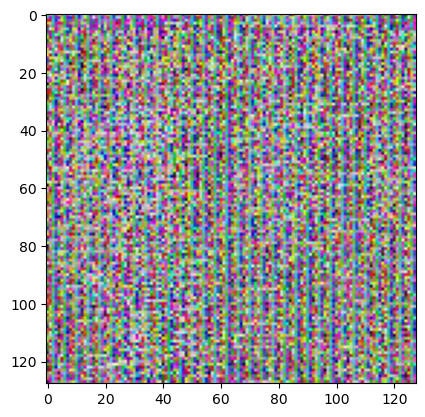

In [11]:
#Creazione e salvataggio dataset di immagini con etichette
panD.create_img_df(path_dir=P_AUDIO_DIR,save_as="pickle",path_out=P_IMG_TRIM_DF,n_ftt=nftt,width=w,height=h)

panImgDF=pd.read_pickle(P_IMG_TRIM_DF)
print(panImgDF.head(3))
imshow(panImgDF["imgSig"][0])

# FILE SYSTEM ->FLAT DATA TRAIN/VAL

In [13]:
data=panD.generate_deep_train_dataset(path_dir=P_IMG_TRIM_DIR,
                            path_out=P_FLAT_IMG_DIR,train_size=0.7,shuffle=True)

Train len: 341 Validation len: 147


In [5]:
data=panD.generate_deep_train_dataset(path_dir=P_AUDIO_TRIM_DIR,
                            path_out=P_FLAT_AUDIO_DIR,train_size=0.7,shuffle=True)

Train len: 341 Validation len: 147
